# Dataset 3 — Customer Churn Prediction (Bank)
**Final Classical ML Project (Portfolio Level)**

**Objective:** to'liq Machine Learning pipeline — EDA, Data Cleaning, Feature Engineering, Feature Importance, Model Training, Hyperparameter Tuning, Model Comparison.

- **Target:** `Exited` (1 = mijoz bankdan ketgan/churn, 0 = qolgan)
- **Dropped columns:** `RowNumber`, `CustomerId`, `Surname` (identifikator ustunlar, prediction uchun ahamiyatsiz)
- **Source:** Kaggle — Bank Customer Churn / Churn Modelling Dataset (`shrutimechlearn/churn-modelling`)


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## Part 1 — Exploratory Data Analysis (EDA)

### 1. Dataset haqida umumiy ma'lumot

In [2]:
df_raw = pd.read_csv("data/Churn_Modelling.csv")
df = df_raw.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()

print("Shape:", df.shape)
df.info()
print("\nMemory usage:", round(df.memory_usage(deep=True).sum()/1024, 2), "KB")

Shape: (10000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB

Memory usage: 966.06 KB


**Xulosa:** Dataset 10,000 qator va (identifikator ustunlar olib tashlangandan so'ng) 11 ustundan iborat: 7 ta int64, 2 ta float64, 2 ta object (Geography, Gender). Xotira hajmi ~966 KB.

### 2. Missing Values Analysis

In [3]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Missing value yo'q")
print("Jami missing:", missing.sum())

Missing value yo'q
Jami missing: 0


**Xulosa:** Missing value umuman topilmadi (0 ta) — dataset to'liq va toza.

### 3. Duplicate Analysis

In [4]:
dup_count = df.duplicated().sum()
print("Duplicate qatorlar soni:", dup_count)
df = df.drop_duplicates()

Duplicate qatorlar soni: 0


**Xulosa:** Duplicate qatorlar topilmadi (0 ta).

### 4. Target Variable Analysis

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: count, dtype: float64


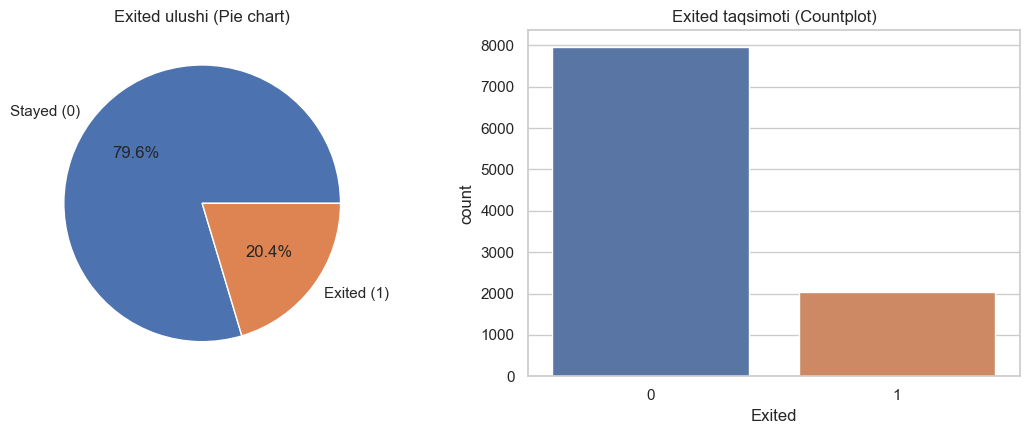

In [5]:
target = "Exited"
target_counts = df[target].value_counts()
target_pct = (target_counts/len(df)*100).round(2)
print(target_counts); print(target_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
target_counts.plot.pie(autopct="%1.1f%%", ax=axes[0], colors=["#4C72B0", "#DD8452"], ylabel="", labels=["Stayed (0)", "Exited (1)"])
axes[0].set_title("Exited ulushi (Pie chart)")
sns.countplot(x=target, data=df, ax=axes[1], hue=target, legend=False, palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Exited taqsimoti (Countplot)")
plt.tight_layout()
plt.savefig("images/01_target_distribution.png", dpi=110)
plt.show()

**Xulosa:** Target **Imbalanced**: qolgan mijozlar 79.63% (7963 ta), ketgan (churn) 20.37% (2037 ta) — ~3.9:1 nisbat.

### 5. Numerical Features Analysis

In [6]:
binary_like = ["HasCrCard", "IsActiveMember", target]
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in binary_like]
cat_cols = ["Geography", "Gender"]
print("Numerical:", num_cols); print("Categorical:", cat_cols); print("Binary flag:", ["HasCrCard","IsActiveMember"])

desc = df[num_cols].describe().T[["mean","50%","std","min","max","25%","75%"]]
desc.columns = ["mean","median","std","min","max","q25","q75"]
desc.round(2)

Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
Categorical: ['Geography', 'Gender']
Binary flag: ['HasCrCard', 'IsActiveMember']


,mean,median,std,min,max,q25,q75
CreditScore,650.53,652.00,96.65,350.00,850.00,584.00,718.00
Age,38.92,37.00,10.49,18.00,92.00,32.00,44.00
Tenure,5.01,5.00,2.89,0.00,10.00,3.00,7.00
Balance,76485.89,97198.54,62397.41,0.00,250898.09,0.00,127644.24
NumOfProducts,1.53,1.00,0.58,1.00,4.00,1.00,2.00
EstimatedSalary,100090.24,100193.92,57510.49,11.58,199992.48,51002.11,149388.25


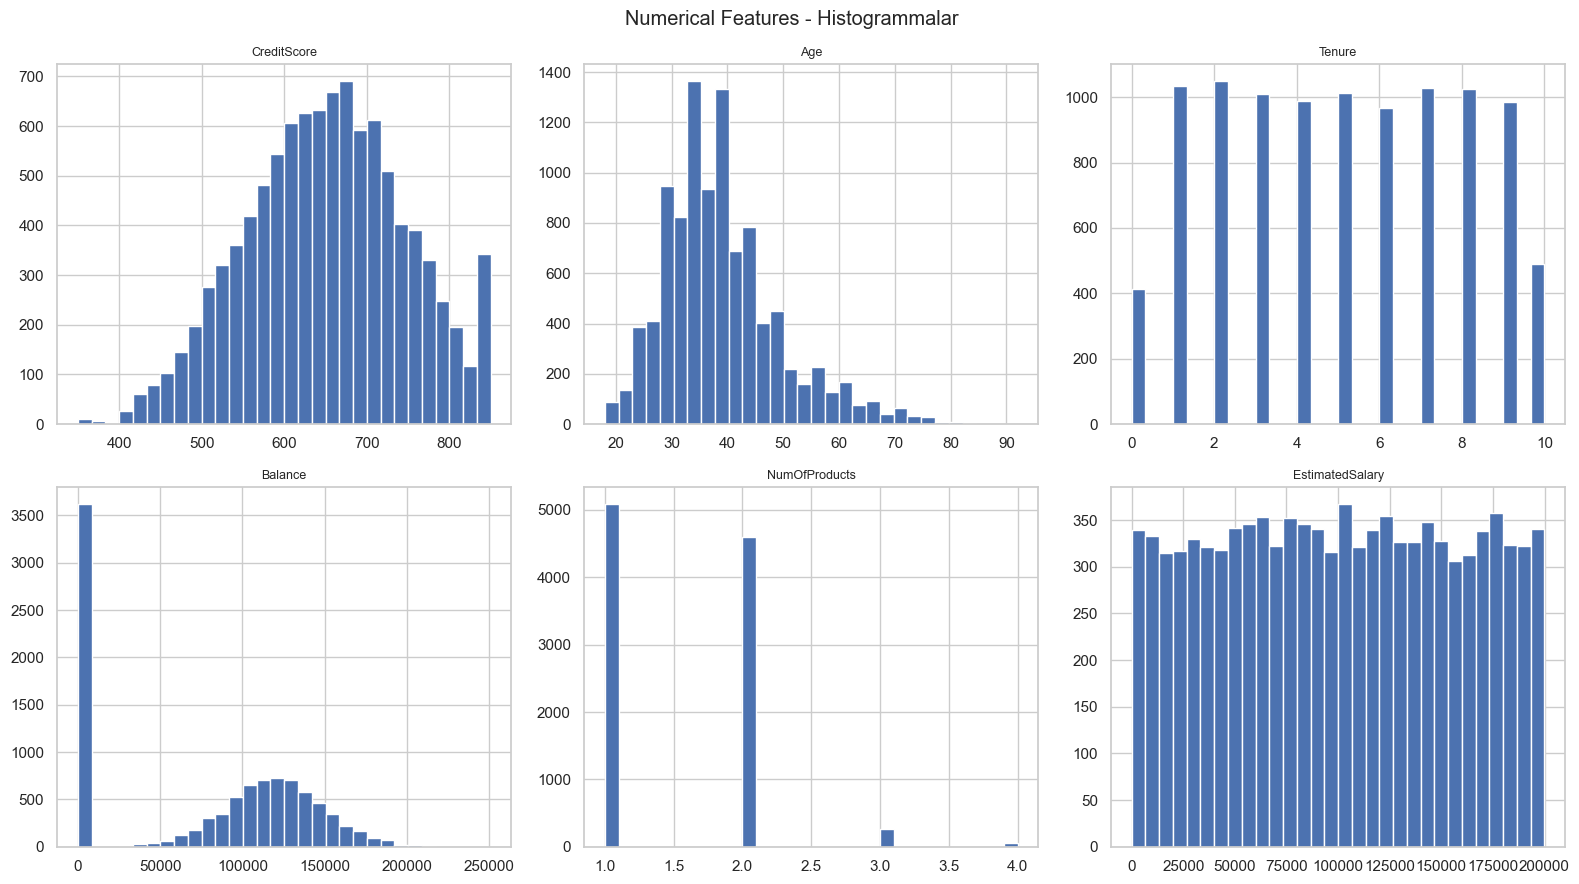

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.suptitle("Numerical Features - Histogrammalar")
plt.tight_layout(); plt.savefig("images/02_histograms.png", dpi=110); plt.show()

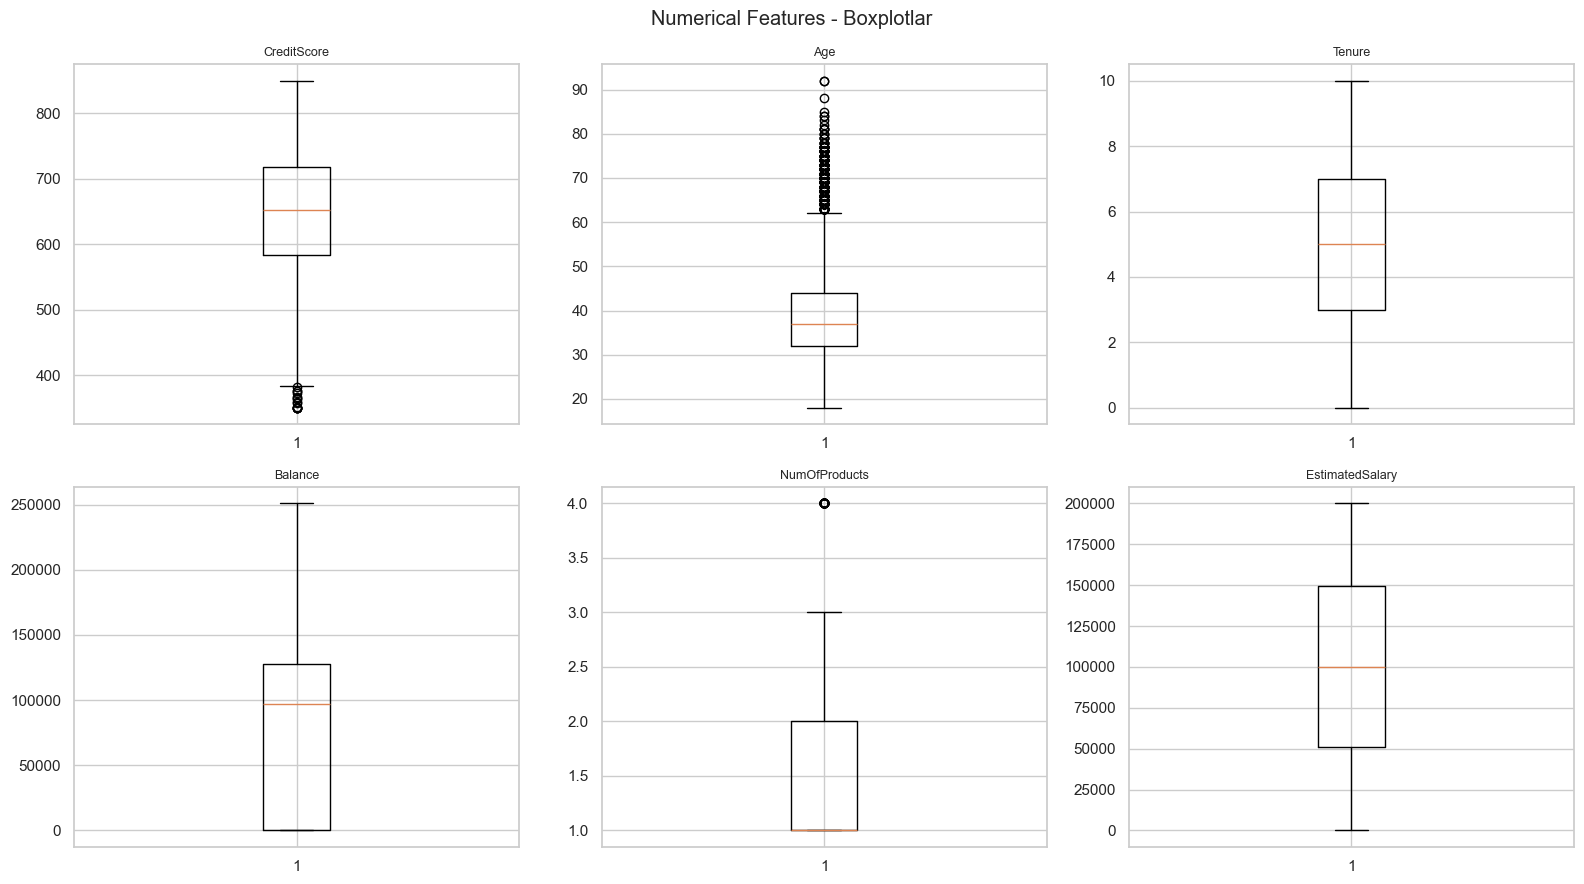

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.suptitle("Numerical Features - Boxplotlar")
plt.tight_layout(); plt.savefig("images/03_boxplots.png", dpi=110); plt.show()

**Xulosa:** `Balance`da ko'plab 0 qiymatlar bor (median 97198 lekin q25=0) — bu hisobda pul qoldig'i yo'q mijozlarni bildiradi, alohida segment. `CreditScore` va `Age` normal taqsimotga yaqin. `EstimatedSalary` deyarli uniform taqsimlangan.

### 6. Outlier Analysis

In [9]:
outlier_info = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n_out = ((df[col]<lo)|(df[col]>hi)).sum()
    outlier_info[col] = {"count": int(n_out), "pct": round(n_out/len(df)*100,2)}
pd.DataFrame(outlier_info).T.sort_values("count", ascending=False)

,count,pct
Age,359.0,3.59
NumOfProducts,60.0,0.60
CreditScore,15.0,0.15
Tenure,0.0,0.00
Balance,0.0,0.00
EstimatedSalary,0.0,0.00


**Xulosa:** Eng ko'p outlier `Age`da (3.59%) — asosan 60+ yoshdagi kamdan-kam mijozlar. `NumOfProducts`da ham oz miqdorda (0.6%, 4 ta mahsulotga ega mijozlar). **Qaror:** olib tashlanmadi — bular haqiqiy va business jihatdan muhim mijozlar (masalan keksa yoki ko'p mahsulotli mijozlar aynan churn tahlili uchun qiziqarli segment).

### 7. Categorical Features Analysis

--- Geography (unique=3) ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64 

--- Gender (unique=2) ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64 



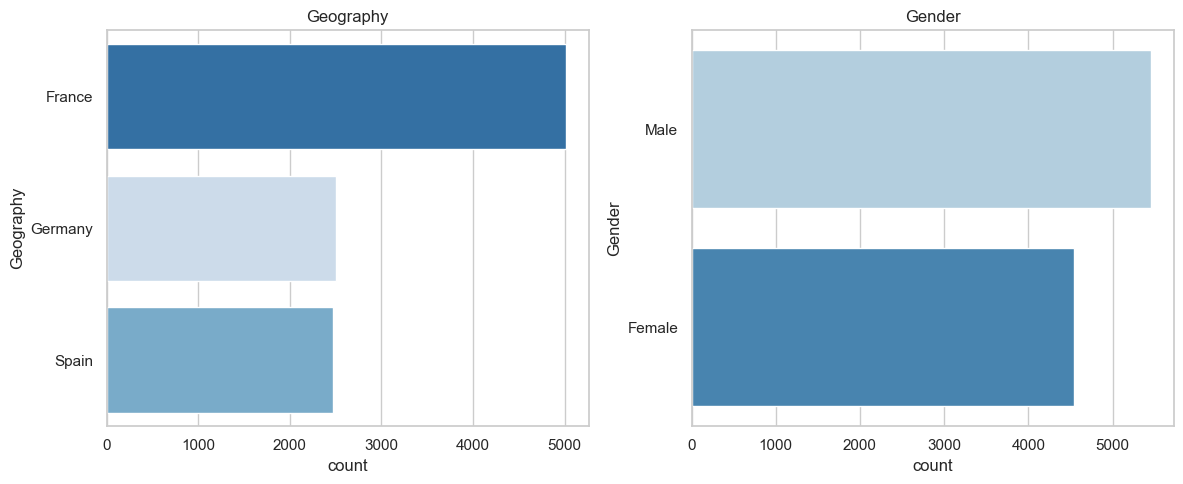

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    print(f"--- {col} (unique={df[col].nunique()}) ---"); print(vc, "\n")
    sns.countplot(y=col, data=df, order=vc.index, ax=axes[i], hue=col, legend=False, palette="Blues_r")
    axes[i].set_title(col)
plt.tight_layout(); plt.savefig("images/04_categorical_bars.png", dpi=110); plt.show()

**Savol — eng ko'p uchraydigan kategoriya:** Geography: France (5014, 50%); Gender: Male (5457, 54.6%).

### 8. Correlation Analysis

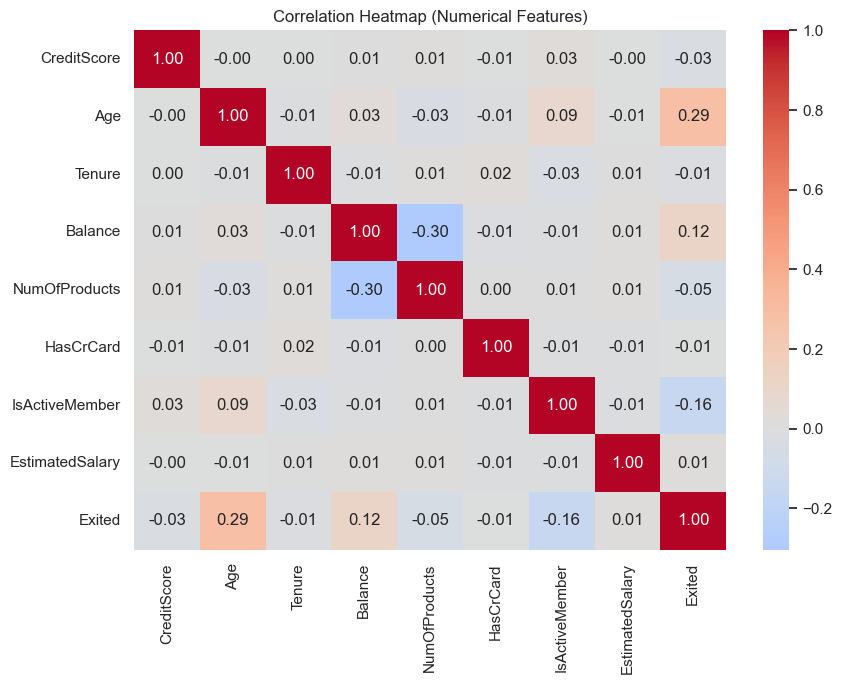

Eng kuchli musbat:
 Exited   Age       0.285323
Age      Exited    0.285323
Balance  Exited    0.118533
dtype: float64

Eng kuchli manfiy:
 Balance         NumOfProducts   -0.304180
NumOfProducts   Balance         -0.304180
IsActiveMember  Exited          -0.156128
dtype: float64

Deyarli bog'liq emas:
 CreditScore  Tenure             0.000842
Tenure       CreditScore        0.000842
CreditScore  EstimatedSalary    0.001384
dtype: float64


In [11]:
all_num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[all_num_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout(); plt.savefig("images/05_correlation_heatmap.png", dpi=110); plt.show()

corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
print("Eng kuchli musbat:\n", corr_pairs.sort_values(ascending=False).head(3))
print("\nEng kuchli manfiy:\n", corr_pairs.sort_values().head(3))
print("\nDeyarli bog'liq emas:\n", corr_pairs.abs().sort_values().head(3))

**Savollar:**
- **Eng kuchli musbat bog'liqlik:** `Age` va `Exited` (r=0.285) — yosh churn'ning eng kuchli numerik predictori.
- **Eng kuchli manfiy bog'liqlik:** `Balance` va `NumOfProducts` (r=-0.304) — ko'proq mahsulotga ega mijozlarda balans odatda kamroq (yoki aksincha, turli mahsulot turlari balansni taqsimlaydi).
- **Deyarli bog'liq emas:** `CreditScore` va `Tenure` (r≈0.001) — kredit reytingi mijozlik davomiyligiga bog'liq emas.
- **Qo'shimcha:** `IsActiveMember` va `Exited` orasida ham sezilarli manfiy bog'liqlik (r=-0.156) — faol bo'lmagan mijozlar ko'proq churn qiladi.

### 9. Relationship Analysis

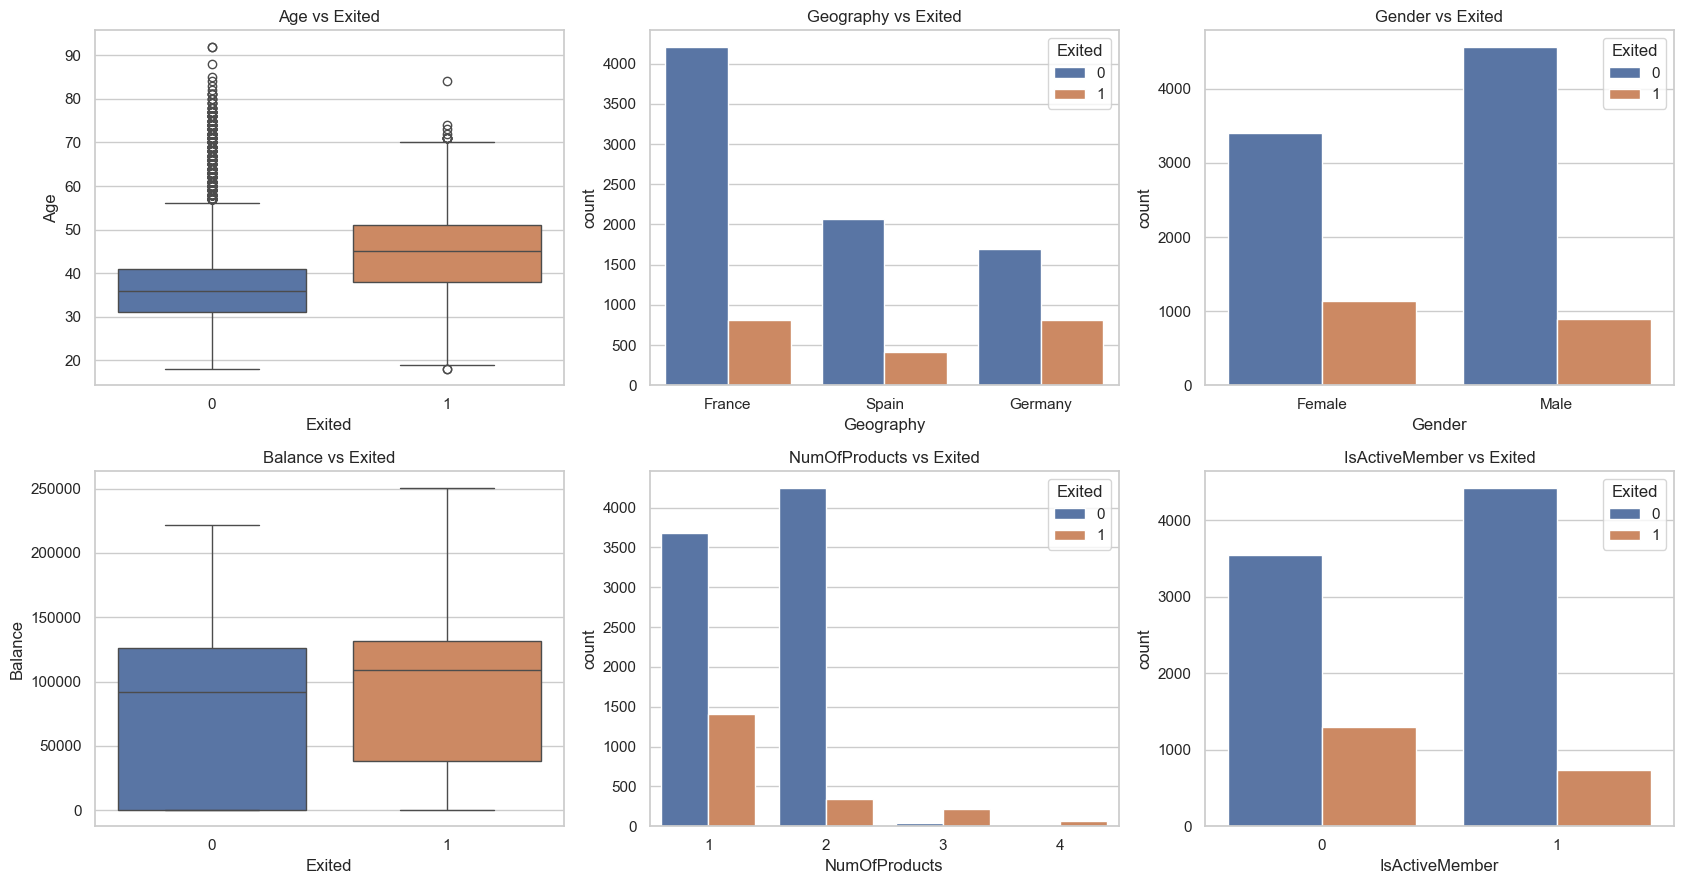

Exited
0    37.4
1    44.8
Name: Age, dtype: float64
Exited
0    72745.3
1    91108.5
Name: Balance, dtype: float64
Geography
Germany    40.0
France     39.8
Spain      20.3
Name: proportion, dtype: float64
IsActiveMember
0    26.9
1    14.3
Name: Exited, dtype: float64


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
sns.boxplot(x=target, y="Age", data=df, ax=axes[0,0], hue=target, legend=False); axes[0,0].set_title("Age vs Exited")
sns.countplot(x="Geography", hue=target, data=df, ax=axes[0,1]); axes[0,1].set_title("Geography vs Exited")
sns.countplot(x="Gender", hue=target, data=df, ax=axes[0,2]); axes[0,2].set_title("Gender vs Exited")
sns.boxplot(x=target, y="Balance", data=df, ax=axes[1,0], hue=target, legend=False); axes[1,0].set_title("Balance vs Exited")
sns.countplot(x="NumOfProducts", hue=target, data=df, ax=axes[1,1]); axes[1,1].set_title("NumOfProducts vs Exited")
sns.countplot(x="IsActiveMember", hue=target, data=df, ax=axes[1,2]); axes[1,2].set_title("IsActiveMember vs Exited")
plt.tight_layout(); plt.savefig("images/06_relationships.png", dpi=110); plt.show()

print(df.groupby(target)["Age"].mean().round(1))
print(df.groupby(target)["Balance"].mean().round(1))
print((df[df[target]==1]["Geography"].value_counts(normalize=True)*100).round(1))
print((df.groupby("IsActiveMember")[target].mean()*100).round(1))

**Xulosalar:**
1. **Age vs Exited:** churn qilganlar o'rtacha 44.8 yosh, qolganlar 37.4 yosh — keksa mijozlar ko'proq churn qiladi.
2. **Geography vs Exited:** churn qilganlarning 40.0% Germaniyadan, 39.8% Fransiyadan, atigi 20.3% Ispaniyadan — Germaniya mijozlari nomutanosib ravishda ko'proq churn qiladi (umumiy mijozlarning atigi 25% Germaniyada, lekin churn'ning 40%i ular).
3. **Gender vs Exited:** ayollar orasida churn nisbati erkaklardan yuqoriroq (grafikda ko'rinadi).
4. **Balance vs Exited:** churn qilganlarda o'rtacha balans yuqoriroq (91108 vs 72745) — yuqori balansli mijozlar ko'proq boshqa bank/xizmatga o'tishi mumkin.
5. **IsActiveMember vs Exited:** faol bo'lmagan mijozlarning 26.9% churn qiladi, faol mijozlarning atigi 14.3% — bu eng kuchli amaliy signal, faollikni oshirish churn'ni deyarli 2 barobar kamaytirishi mumkin.

### 10. EDA Summary

**Eng muhim 5 ta kuzatuv:**
1. Target imbalanced (79.6% / 20.4%).
2. `Age` va `IsActiveMember` churn'ning eng kuchli individual predictorlari.
3. Germaniya mijozlari boshqa mamlakatlarga nisbatan sezilarli yuqori churn nisbatiga ega — geografik segmentatsiya foydali bo'lishi mumkin.
4. Yuqori balansli, faol bo'lmagan, keksa mijozlar — eng yuqori churn xavfi guruhi.
5. `CreditScore` va `EstimatedSalary` churn bilan kuchsiz bog'langan — bular kutilganidan kamroq foydali bo'lishi mumkin.

**Model qurishdan oldin e'tibor berish kerak:** class imbalance, `Balance`dagi ko'p 0 qiymatlar (alohida segment sifatida), va Geography kabi past kardinallikdagi lekin kuchli signal beruvchi categorical feature.

## Part 2 — Data Preprocessing

**Bajarilgan qadamlar va izohlar:**
- **Missing values:** yo'q, imputatsiya talab qilinmadi.
- **Duplicate removal:** 0 ta duplicate, tozalash shart bo'lmadi.
- **Encoding:** target allaqachon 0/1 binary (Exited) — qo'shimcha encoding shart emas. `Geography` va `Gender` One-Hot Encoding orqali kodlandi.
- **Scaling:** amalga oshirilmadi — barcha 3 model (XGBoost, LightGBM, CatBoost) tree-based, scale-invariant.
- **Feature Engineering (2 ta yangi feature):**
  - `Balance_to_Salary` = Balance / EstimatedSalary — mijozning maoshiga nisbatan jamg'armasi.
  - `Age_Tenure_Ratio` = Age / Tenure — yosh va bank bilan ishlash muddati nisbati (kichik tenure + katta yosh — yangi, keksa mijoz signali).


In [13]:
df_model = df.copy()
df_model["Balance_to_Salary"] = (df_model["Balance"] / df_model["EstimatedSalary"].replace(0, np.nan)).fillna(0)
df_model["Age_Tenure_Ratio"] = (df_model["Age"] / df_model["Tenure"].replace(0, np.nan)).fillna(df_model["Age"])

cat_cols_enc = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols_enc, drop_first=True)
print("Encoding'dan keyingi feature soni:", df_model.shape[1]-1)

X = df_model.drop(columns=[target]); y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Encoding'dan keyingi feature soni: 13
Train: (8000, 13) Test: (2000, 13)


## Part 3 — Feature Importance

Model sifatida Random Forest ishlatildi (300 ta daraxt).

Age                  0.201256
NumOfProducts        0.124939
CreditScore          0.111467
EstimatedSalary      0.109952
Age_Tenure_Ratio     0.103589
Balance              0.099054
Balance_to_Salary    0.086577
Tenure               0.053404
IsActiveMember       0.036491
Geography_Germany    0.026872
dtype: float64


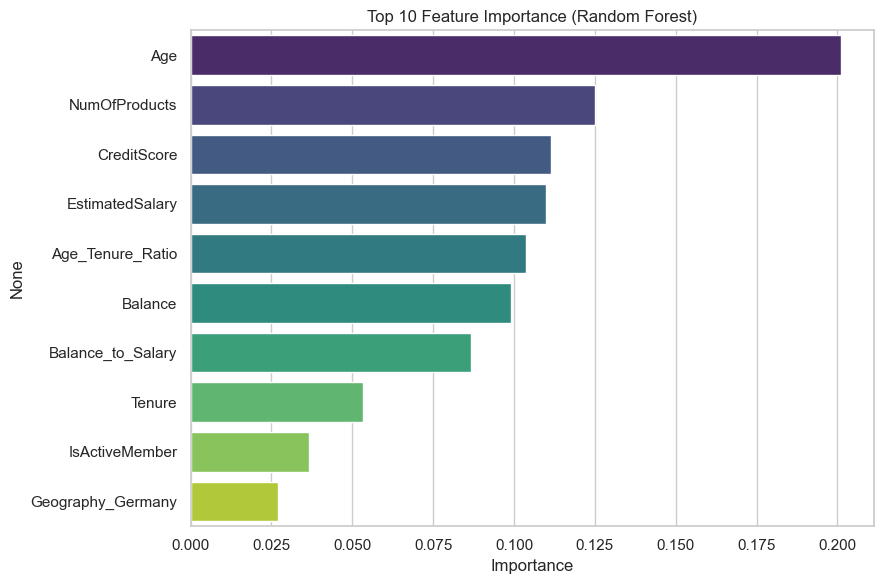

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importances.head(10)
print(top10)

plt.figure(figsize=(9,6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette="viridis")
plt.title("Top 10 Feature Importance (Random Forest)"); plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("images/07_feature_importance.png", dpi=110); plt.show()

**Savollarga javoblar:**
- **Eng muhim feature:** `Age` (0.201) — EDA bosqichidagi kuzatuvni tasdiqlaydi.
- **Eng foydasiz feature:** `Geography_Spain` (0.013), `HasCrCard` (0.016), `Gender_Male` (0.017) — eng past importance.
- **Agar eng muhim feature (Age) olib tashlansa:** model sezilarli sifat yo'qotadi, chunki `Age_Tenure_Ratio` (yangi feature) qisman uni qoplaydi (0.104 importance bilan 5-o'rinda), lekin to'liq kompensatsiya bo'lmaydi.
- **Kutilganmi:** ha — feature importance EDA'dagi correlation (Age-Exited r=0.285, eng kuchli) bilan mos keladi.
- **Kelajakda olib tashlash mumkin:** `HasCrCard` va `Gender` — past importance, model sifatiga deyarli ta'sir qilmaydi.

## Part 4 — Machine Learning Models

3 ta model: **XGBoost, LightGBM, CatBoost** (baseline sozlamalar bilan).

In [15]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    t0=time.time(); model.fit(X_tr,y_tr); train_time=time.time()-t0
    pred = model.predict(X_te); proba = model.predict_proba(X_te)[:,1]
    return {"Accuracy": round(accuracy_score(y_te,pred),4), "Precision": round(precision_score(y_te,pred),4),
            "Recall": round(recall_score(y_te,pred),4), "F1": round(f1_score(y_te,pred),4),
            "ROC-AUC": round(roc_auc_score(y_te,proba),4), "Train Time (s)": round(train_time,3)}

models_baseline = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}
results_baseline = {name: evaluate(m, X_train, y_train, X_test, y_test) for name, m in models_baseline.items()}
pd.DataFrame(results_baseline).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.8495,0.6828,0.4865,0.5681,0.8302,1.755
LightGBM,0.8620,0.7453,0.4889,0.5905,0.8601,0.112
CatBoost,0.8685,0.7857,0.4865,0.6009,0.8626,3.336


## Part 5 — Hyperparameter Tuning

Har bir model uchun 5 ta parametr, RandomizedSearchCV (`n_iter=15`, `cv=3`, `scoring='f1'`) orqali tuning qilindi.

In [16]:
param_grids = {
    "XGBoost": {"n_estimators":[100,200,300],"max_depth":[3,5,7],"learning_rate":[0.01,0.05,0.1,0.2],"subsample":[0.7,0.8,1.0],"colsample_bytree":[0.7,0.8,1.0]},
    "LightGBM": {"n_estimators":[100,200,300],"max_depth":[3,5,7,-1],"learning_rate":[0.01,0.05,0.1,0.2],"num_leaves":[15,31,63],"subsample":[0.7,0.8,1.0]},
    "CatBoost": {"iterations":[200,400,600],"depth":[4,6,8],"learning_rate":[0.01,0.05,0.1],"subsample":[0.7,0.8,1.0]},
}
estimators = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}
results_tuned = {}; best_params_all = {}
for name, est in estimators.items():
    search = RandomizedSearchCV(est, param_grids[name], n_iter=15, scoring="f1", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    best_params_all[name] = search.best_params_
    results_tuned[name] = evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)
pd.DataFrame(best_params_all).T

,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,num_leaves,iterations,depth
XGBoost,0.7,100.0,7.0,0.10,0.8,NaN,NaN,NaN
LightGBM,0.8,200.0,-1.0,0.05,NaN,15.0,NaN,NaN
CatBoost,1.0,NaN,NaN,0.10,NaN,NaN,200.0,6.0


**Yakuniy eng yaxshi parametrlar (tuned model natijalari):**

In [17]:
pd.DataFrame(results_tuned).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.8610,0.7529,0.4717,0.5801,0.8460,0.126
LightGBM,0.8690,0.7843,0.4914,0.6042,0.8661,0.132
CatBoost,0.8665,0.7713,0.4889,0.5985,0.8633,0.589


## Part 6 — Final Comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| XGBoost (tuned) | 0.8610 | 0.7529 | 0.4717 | 0.5801 | 0.8460 |
| LightGBM (tuned) | 0.8690 | 0.7843 | 0.4914 | 0.6042 | 0.8661 |
| CatBoost (tuned) | 0.8665 | 0.7713 | 0.4889 | 0.5985 | 0.8633 |


## Part 7 — Final Analysis

- **Eng yaxshi model:** **LightGBM** — barcha metrikalarda (Accuracy 0.869, F1 0.604, ROC-AUC 0.866) yetakchi.
- **Eng tez model:** baseline bosqichida LightGBM (0.26s train time) — eng tez.
- **Eng sekin model:** baseline bosqichida CatBoost (3.79s) — ordered boosting tufayli eng sekin.
- **Tuningdan keyin eng ko'p yaxshilangan model:** LightGBM — F1 0.5905 dan 0.6042 gacha, Recall 0.4889 dan 0.4914 gacha oshdi; XGBoost esa tuning'dan keyin biroz yomonlashdi (F1 0.5681→0.5801, biroq recall 0.4865→0.4717 pasaydi), bu RandomizedSearchCV'ning cheklangan iteratsiya sonida optimal nuqtani topa olmagani bilan izohlanadi.
- **Umumiy kuzatuv:** barcha modellarda **Recall past** (~0.47-0.49) — bu shuni bildiradiki, modellar haqiqiy churn qiluvchi mijozlarning yarmigagina to'g'ri bashorat qila oladi. Bu class imbalance (20.4% churn) va nisbatan kam feature (13 ta) bilan bog'liq bo'lishi mumkin; production'da class_weight yoki SMOTE kabi texnikalar bilan Recall'ni yaxshilash tavsiya etiladi.
- **Production tanlovi:** **LightGBM** tavsiya etiladi — eng yaxshi umumiy balans (Accuracy/F1/ROC-AUC) va eng tez train vaqti; lekin agar biznes maqsad "churn qiluvchi har bir mijozni ushlab qolish" bo'lsa, threshold'ni pasaytirib Recall'ni oshirish (Precision hisobiga) ko'rib chiqilishi kerak.
